# Fig. 2D source-data tables

Renders publication-ready tables (PDF, Arial 7 pt, 170 mm wide; no title or caption, those are added in LaTeX) of the estimated FDR vs. local barcode density for the three datasets in Fig. 2D, plus formatted CSVs for editable submission.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['font.family'] = 'Arial'
mpl.rcParams['font.size'] = 7

## Load the data

The three CSVs don't share a layout, so each gets its own loader that returns the same columns:
`density, gene, nc, fdr, ci_low, ci_high` (CI bounds as absolute FDR values).

- `mouse_cortex_dens_eFDR_plot_lvf7 copy.csv` and `sfp_curve copy.csv`: `error_lower`/`error_upper` are distances from the estimate.
- `RS_culture_fig2d.csv`: `error_lower`/`error_upper` are the CI bounds themselves.
- `sfp_curve copy.csv` has an unlabeled local-density column (5 header names, 6 values per data row) and a 5-field density-0 row, so column names are supplied explicitly and that row is skipped.

In [2]:
def load_mouse_cortex(path):
    df = pd.read_csv(path)
    return pd.DataFrame({
        "density": df["local_density"],
        "gene": df["gene_encoding_barcodes"],
        "nc": df["negative_control_barcodes"],
        "fdr": df["est_fdr_100nm"],
        "ci_low": df["est_fdr_100nm"] - df["error_lower"],
        "ci_high": df["est_fdr_100nm"] + df["error_upper"],
    })


def load_rs_culture(path):
    df = pd.read_csv(path)
    return pd.DataFrame({
        "density": df["local_density"],
        "gene": df["gen"],
        "nc": df["nc"],
        "fdr": df["est_fdr_100nm"],
        "ci_low": df["error_lower"],
        "ci_high": df["error_upper"],
    })


def load_sfp(path):
    names = ["local_density", "fdr", "error_lower", "error_upper",
             "gene_encoding_barcodes", "negative_control_barcodes"]
    # Skip the header and the 5-field all-zero density-0 row
    df = pd.read_csv(path, header=None, skiprows=2, names=names)
    return pd.DataFrame({
        "density": df["local_density"],
        "gene": df["gene_encoding_barcodes"],
        "nc": df["negative_control_barcodes"],
        "fdr": df["fdr"],
        "ci_low": df["fdr"] - df["error_lower"],
        "ci_high": df["fdr"] + df["error_upper"],
    })


# gene_to_nc_codewords: ratio of gene-encoding to negative-control codewords used in the FDR estimate
datasets = {
    "sfp": dict(
        data=load_sfp("sfp_curve copy.csv"),
        gene_to_nc_codewords=10000 / 14000,
    ),
    "rs_mouse_cortex": dict(
        data=load_mouse_cortex("mouse_cortex_dens_eFDR_plot_lvf7 copy.csv"),
        gene_to_nc_codewords=271 / (2100 - 271),
    ),
    "rs_nih3t3": dict(
        data=load_rs_culture("RS_culture_fig2d.csv"),
        gene_to_nc_codewords=271 / (2100 - 271),
    ),
}

# Density 0 is an all-zero placeholder row
for d in datasets.values():
    d["data"] = d["data"][d["data"]["density"] >= 1].reset_index(drop=True)

## Sanity checks

The reported FDR should match the counts, and each CI should bracket its estimate.

In [3]:
for key, d in datasets.items():
    df = d["data"]
    recomputed = df["nc"] * d["gene_to_nc_codewords"] / df["gene"]
    assert np.allclose(recomputed, df["fdr"], rtol=1e-6), f"{key}: FDR does not match counts"
    assert ((df["ci_low"] <= df["fdr"]) & (df["fdr"] <= df["ci_high"])).all(), f"{key}: CI does not bracket FDR"
print("All checks passed")

All checks passed


## Format

In [7]:
FDR_DECIMALS = 2  # decimals shown for FDR and CI, in percent


def format_table(df):
    pct = lambda x: f"{100 * x:.{FDR_DECIMALS}f}"
    return pd.DataFrame({
        "# of barcodes within 100 nm": df["density"].astype(int).astype(str),
        "# of gene encoding barcodes ": df["gene"].map(lambda x: f"{x:,.0f}"),
        "# of negative control barcodes ": df["nc"].map(lambda x: f"{x:,.0f}"),
        "Estimated FDR (%)": df["fdr"].map(pct),
        "95% CI for FDR (%)": [f"{pct(lo)}–{pct(hi)}" for lo, hi in zip(df["ci_low"], df["ci_high"])],
    })


for d in datasets.values():
    d["table"] = format_table(d["data"])

datasets["sfp"]["table"]

,# of barcodes within 100 nm,# of gene encoding barcodes,# of negative control barcodes,Estimated FDR (%),95% CI for FDR (%)
0,1,"4,515,118","161,699",2.56,2.55–2.57
1,2,"1,365,608","69,482",3.63,3.61–3.66
2,3,"234,687","20,631",6.28,6.19–6.37
3,4,"34,379","6,626",13.77,13.41–14.14
4,5,"8,054","3,243",28.76,27.62–29.96
5,6,"4,070","2,144",37.63,35.68–39.67
6,7,"2,844","1,581",39.71,37.30–42.23


## Render

In [12]:
def _text_width(ax, s, **kw):
    """Rendered width of a (possibly multi-line) string, in inches."""
    t = ax.text(0, 0, s, **kw)
    w = t.get_window_extent(ax.figure.canvas.get_renderer()).width / ax.figure.dpi
    t.remove()
    return w


def _split_header(s):
    """Split a header into two lines at the space that gives the most balanced halves."""
    words = s.split()
    if len(words) < 2:
        return s
    best = min(range(1, len(words)),
               key=lambda i: abs(len(" ".join(words[:i])) - len(" ".join(words[i:]))))
    return " ".join(words[:best]) + "\n" + " ".join(words[best:])


def render_table(table, path, width_mm=140, min_gap=0.15):
    """Draw a booktabs-style table (top/mid/bottom rules, no vertical lines) and save it.

    Each column is as wide as its widest entry; leftover width is spread evenly between
    columns. If the headers don't fit with at least `min_gap` inches between columns,
    headers wider than their column's data are wrapped onto two lines.
    """
    row_h = 0.15  # inches per table row
    pad = 0.06    # inches between rules and text
    edge = 0.02   # inches of blank space above the top rule and below the bottom rule
    margin = 0.05
    header_kw = dict(fontweight="bold", linespacing=1.2)

    fig_w = width_mm / 25.4
    fig = plt.figure(figsize=(fig_w, 1))
    ax = fig.add_axes([0, 0, 1, 1])
    ax.axis("off")

    # Fit columns to their content
    headers = [str(c).strip() for c in table.columns]
    data_w = [max(_text_width(ax, str(v)) for v in table[c]) for c in table.columns]
    head_w = [_text_width(ax, h, **header_kw) for h in headers]
    avail = fig_w - 2 * margin
    if sum(max(d, h) for d, h in zip(data_w, head_w)) + min_gap * len(headers) > avail:
        headers = [_split_header(h) if hw > dw else h for h, hw, dw in zip(headers, head_w, data_w)]
        head_w = [_text_width(ax, h, **header_kw) for h in headers]
    col_w = [max(d, h) for d, h in zip(data_w, head_w)]
    gap = (avail - sum(col_w)) / len(col_w)
    col_x, x = [], margin
    for w in col_w:
        col_x.append(x + (gap + w) / 2)
        x += gap + w

    n_head_lines = max(h.count("\n") + 1 for h in headers)
    head_h = row_h * (1 + 0.85 * (n_head_lines - 1))
    fig_h = head_h + row_h * len(table) + 2 * pad + 2 * edge
    fig.set_size_inches(fig_w, fig_h)
    ax.set_xlim(0, fig_w)
    ax.set_ylim(0, fig_h)
    rule = dict(color="black", solid_capstyle="butt")

    y = fig_h - edge
    ax.plot([margin, fig_w - margin], [y, y], lw=0.8, **rule)

    y -= pad / 2
    for x, h in zip(col_x, headers):
        ax.text(x, y - head_h / 2, h, ha="center", va="center", multialignment="center", **header_kw)
    y -= head_h + pad / 2
    ax.plot([margin, fig_w - margin], [y, y], lw=0.5, **rule)

    y -= pad / 2
    for _, row in table.iterrows():
        for x, val in zip(col_x, row):
            ax.text(x, y - row_h / 2, str(val), ha="center", va="center")
        y -= row_h
    y -= pad / 2
    ax.plot([margin, fig_w - margin], [y, y], lw=0.8, **rule)

    fig.savefig(path)
    return fig

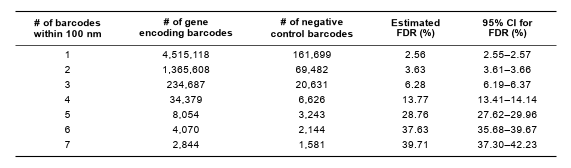

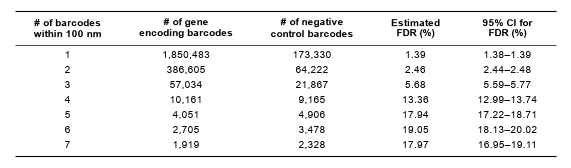

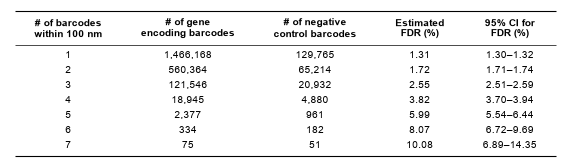

In [13]:
for key, d in datasets.items():
    render_table(d["table"], f"Table_Fig2D_{key}.pdf")
    d["table"].to_csv(f"Table_Fig2D_{key}.csv", index=False, encoding="utf-8-sig")
plt.show()